# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


In [0]:
import pandas as pd
import numpy as np

In [0]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [0]:
from keras.datasets import cifar10

In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 4s 0us/step


In [7]:
X_train.shape

(50000, 32, 32, 3)

Label: [9]


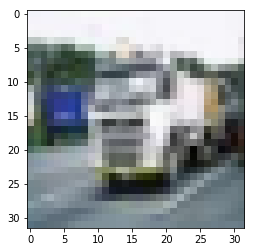

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
print("Label: {}".format(y_train[1000]))
plt.imshow(X_train[1000], cmap='gray')

In [0]:
#First Train Dataset => 0 to 4
X_train_0_4 = np.asarray([X_train[key] for (key, label) in enumerate(y_train) if int(label) >= 0 and int(label) <= 4])
#Second Train Dataset => 5 to 9
X_train_5_9 = np.asarray([X_train[key] for (key, label) in enumerate(y_train) if int(label) >= 5 and int(label) <= 9])

#First Test Dataset => 0 to 4
X_test_0_4 = np.asarray([X_test[key] for (key, label) in enumerate(y_test) if int(label) >= 0 and int(label) <= 4])
#Second Test Dataset => 5 to 9
X_test_5_9 = np.asarray([X_test[key] for (key, label) in enumerate(y_test) if int(label) >= 5 and int(label) <= 9])

In [0]:
#First Train Label => 0 to 4
y_train_0_4 = y_train[np.where((y_train >= 0 ) & (y_train <= 4))]
#Second Train Label => 5 to 9
y_train_5_9 =  y_train[np.where((y_train >= 5 ) & (y_train <= 9))]

#First Test Label => 0 to 4
y_test_0_4 = y_test[np.where((y_test >= 0 ) & (y_test <= 4))]
#Second Test Label => 5 to 9
y_test_5_9 =  y_test[np.where((y_test >= 5 ) & (y_test <= 9))]

In [11]:
type(X_train_0_4)

numpy.ndarray

In [21]:
np.unique(y_train_0_4)

array([0, 1, 2, 3, 4], dtype=uint8)

In [22]:
np.unique(y_train_5_9)

array([5, 6, 7, 8, 9], dtype=uint8)

In [20]:
print("0 to 4 Train Data Shape : {0}".format(X_train_0_4.shape))
print("5 to 9 Train Data Shape : {0}".format(X_train_5_9.shape))

print("0 to 4 Test Data Shape : {0}".format(X_test_0_4.shape))
print("5 to 9 Test Data Shape : {0}".format(X_test_5_9.shape))

0 to 4 Train Data Shape : (25000, 32, 32, 3)
5 to 9 Train Data Shape : (25000, 32, 32, 3)
0 to 4 Test Data Shape : (5000, 32, 32, 3)
5 to 9 Test Data Shape : (5000, 32, 32, 3)


In [23]:
X_train_0_4[0].shape

(32, 32, 3)

### Normalize data
- normalize first dataset
- we must normalize our data as it is always required in neural network models
- we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
- normalize X_train and X_test
- make sure that the values are float so that we can get decimal points after division

In [0]:
X_train_0_4_Nor = X_train_0_4.astype('float32') / 255
X_test_0_4_Nor = X_test_0_4.astype('float32') / 255

### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [0]:
# Convert class vectors to binary class matrices
y_train_0_4 = keras.utils.to_categorical(y_train_0_4, 5)
y_test_0_4 = keras.utils.to_categorical(y_test_0_4, 5)

### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [0]:
#Initialize model, reshape & normalize data
model1 = tf.keras.models.Sequential()

In [0]:
model1.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,  activation='relu', input_shape=(32,32,3)))
#model1.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,  activation='relu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model1.add(tf.keras.layers.Dropout(0.2))

In [0]:
#Add Flatten Layer
model1.add(tf.keras.layers.Flatten())

In [0]:
#Add - Dense Layer - 128 Nurons with Relu
model1.add(tf.keras.layers.Dense(64, activation='relu'))
#Add - Dense Layer - 128 Nurons with Relu
model1.add(tf.keras.layers.Dense(64, activation='relu'))
#Add - Dense Layer/output layer - 5 Nurons with Softmax
model1.add(tf.keras.layers.Dense(5, activation='softmax'))

In [0]:
# compile model
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [68]:
# Fit the model1 with 30 epochs and batch size 128 for train and validation data
m1_history=model1.fit(X_train_0_4_Nor, y_train_0_4, 
          validation_data=(X_test_0_4_Nor, y_test_0_4), 
          epochs=30,
          batch_size=128)

Train on 25000 samples, validate on 5000 samples
Epoch 1/30
25000/25000 [==============================] - 34s 1ms/sample - loss: 1.0972 - acc: 0.5460 - val_loss: 0.8895 - val_acc: 0.6442
Epoch 2/30
25000/25000 [==============================] - 33s 1ms/sample - loss: 0.8699 - acc: 0.6545 - val_loss: 0.8071 - val_acc: 0.6780
Epoch 3/30
25000/25000 [==============================] - 33s 1ms/sample - loss: 0.7712 - acc: 0.7029 - val_loss: 0.7961 - val_acc: 0.6844
Epoch 4/30
25000/25000 [==============================] - 33s 1ms/sample - loss: 0.7165 - acc: 0.7237 - val_loss: 0.7437 - val_acc: 0.7128
Epoch 5/30
25000/25000 [==============================] - 33s 1ms/sample - loss: 0.6739 - acc: 0.7417 - val_loss: 0.7515 - val_acc: 0.7082
Epoch 6/30
25000/25000 [==============================] - 33s 1ms/sample - loss: 0.6441 - acc: 0.7544 - val_loss: 0.7421 - val_acc: 0.7274
Epoch 7/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.6032 - acc: 0.7716 - val_loss: 0.7

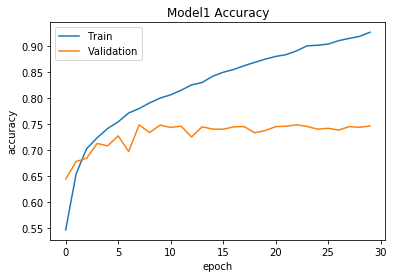

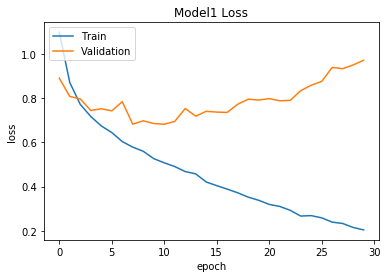

In [69]:
# summarize history for accuracy
plt.plot(m1_history.history['acc'])
plt.plot(m1_history.history['val_acc'])
plt.title('Model1 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m1_history.history['loss'])
plt.plot(m1_history.history['val_loss'])
plt.title('Model1 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [0]:
#Set pre-trained model layers only dense layer to trainable
for layer in model1.layers:
  if(str(layer).find(".Dense") != -1):
    layer.trainable = True

In [125]:
for layer in model1.layers:
 print(layer, layer.trainable)

<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x7f2b098cce10> False
<tensorflow.python.keras.layers.pooling.MaxPooling2D object at 0x7f2b098ccc50> False
<tensorflow.python.keras.layers.core.Dropout object at 0x7f2b0985f748> False
<tensorflow.python.keras.layers.core.Flatten object at 0x7f2b098b7710> False
<tensorflow.python.keras.layers.core.Dense object at 0x7f2b09843be0> True
<tensorflow.python.keras.layers.core.Dense object at 0x7f2b09843898> True
<tensorflow.python.keras.layers.core.Dense object at 0x7f2b0986b160> True


### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

#### One Hot Encode

In [0]:
#One hot encode 5-9 lables
y_train_5_9=y_train_5_9-5
y_test_5_9=y_test_5_9-5

In [0]:
# Convert class vectors to binary class matrices
y_train_5_9 = keras.utils.to_categorical(y_train_5_9, 5)
y_test_5_9 = keras.utils.to_categorical(y_test_5_9, 5)

### Normalize data
1. normalize second data
2. we must normalize our data as it is always required in neural network models
3. we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
4. normalize X_train and X_test
5. make sure that the values are float so that we can get decimal points after division

In [0]:
X_train_5_9_Nor = X_train_5_9.astype('float32') / 255
X_test_5_9_Nor = X_test_5_9.astype('float32') / 255

In [131]:
print("First Dataset (5 to 9) X-Train Shape : {0} ".format(X_train_5_9_Nor.shape)) 
print("First Dataset (5 to 9) X-Train data number of images : {0} ".format(X_train_5_9_Nor.shape[0])) 
print("First Dataset (5 to 9) X-test data number of images : {0} ".format(X_test_5_9_Nor.shape[0])) 

First Dataset (5 to 9) X-Train Shape : (25000, 32, 32, 3) 
First Dataset (5 to 9) X-Train data number of images : 25000 
First Dataset (5 to 9) X-test data number of images : 5000 


In [133]:
 # Fit the model1 with 30 epochs and batch size 128 for train and validation data
m1_history1=model1.fit(X_train_5_9_Nor, y_train_5_9, 
          validation_data=(X_test_5_9_Nor, y_test_5_9), 
          epochs=30,
          batch_size=128)

Train on 25000 samples, validate on 5000 samples
Epoch 1/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.7130 - acc: 0.7392 - val_loss: 0.6075 - val_acc: 0.7802
Epoch 2/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.5180 - acc: 0.8135 - val_loss: 0.5040 - val_acc: 0.8192
Epoch 3/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.4412 - acc: 0.8446 - val_loss: 0.4680 - val_acc: 0.8290
Epoch 4/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.4013 - acc: 0.8559 - val_loss: 0.4553 - val_acc: 0.8354
Epoch 5/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.3673 - acc: 0.8693 - val_loss: 0.4547 - val_acc: 0.8346
Epoch 6/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.3470 - acc: 0.8764 - val_loss: 0.4899 - val_acc: 0.8236
Epoch 7/30
25000/25000 [==============================] - 32s 1ms/sample - loss: 0.3189 - acc: 0.8874 - val_loss: 0.4

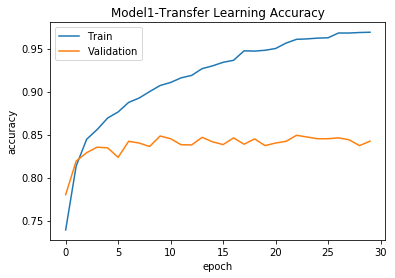

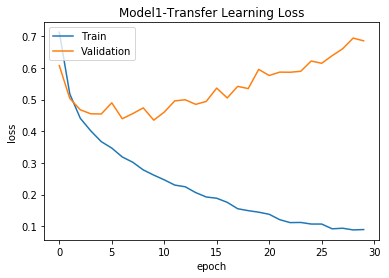

In [134]:
# summarize history for accuracy
plt.plot(m1_history1.history['acc'])
plt.plot(m1_history1.history['val_acc'])
plt.title('Model1-Transfer Learning Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m1_history1.history['loss'])
plt.plot(m1_history1.history['val_loss'])
plt.title('Model1-Transfer Learning Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [107]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [109]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [110]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [111]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

In [113]:
type(twenty_train)

sklearn.utils.Bunch

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [0]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score